In [22]:
import os
from glob import glob
import pandas as pd
import numpy as np
import pickle
from spectral.io import envi
import matplotlib.pyplot as plt

from spectral.io import envi

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

os.chdir('/store/carroll/col/data/2025/')

In [44]:
insitu = pd.read_csv('insitu/insitu_validation_target_mean.csv')
wvl_cols = [x for x in insitu.columns if x not in ['file_tag','date','site','utm_x','utm_y']]

wl_neon = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000 # nm
wl_asd = np.loadtxt('/store/carroll/col/data/wavelengths_asd.txt')[:,0]
wl_neon_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')
wl_nan = wl_neon_nan

base_dir = 'validation/'

def closest_wl(wl, mv):
    return np.nanargmin(np.abs(wl-mv))
wl_asd[closest_wl(wl_asd, 1360):closest_wl(wl_asd, 1410)] = np.nan
wl_asd[closest_wl(wl_asd, 1800):closest_wl(wl_asd, 1970)] = np.nan

fp = 'validation/single_val_pxs_rdn_obs_loc.pkl'
with open(fp, 'rb') as f:
    single_px = pickle.load(f)

rcc_path = 'rccs/rcc_snodgrass_mean_6c_processed.txt'
rcc = np.loadtxt(rcc_path)

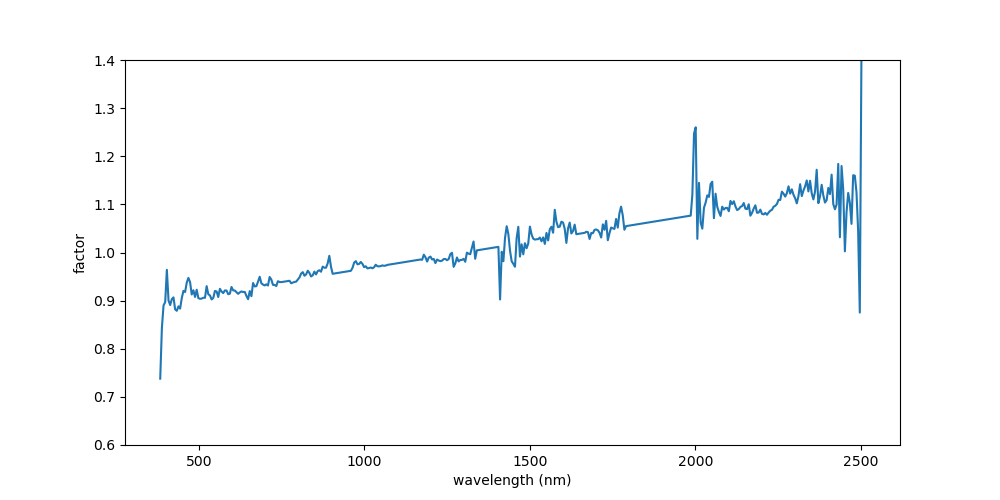

In [40]:
# load all rccs

fig = plt.figure(figsize=(10,5))

plt.plot(wl_neon, rcc)
plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.ylim(0.6,1.4)
plt.show()

In [23]:
fids = [x for x in glob('validation/*') if 'NIS01' in x]
fids = [x.split('/')[-1] for x in fids if 'carboncreek' not in x]
file_tags = sorted(list(set(['_'.join(x.split('_')[6:]).removesuffix('_6c') for x in fids])))
file_tags

['20250621_low_talus_slope',
 '20250621_rainbow_park_grass',
 '20250626_airpark',
 '20250626_dirt',
 '20250626_grass',
 '20250626_sand',
 '20250626_veg_slope_1',
 '20250709_EL_val1',
 '20250709_matterhornlot',
 '20250714_savoy_gravel']

In [ ]:
fid = site_fids[0]
print(fid)

fp_config = glob(os.path.join(base_dir, fid, 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp_config)

# update config
config.input.radiometry_correction_file = rcc_path

# set up forward model, io, inv according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the single pixel representation
rdn_ = single_px[file_tag][fid.removesuffix('_6c')]['rdn']
obs_ = single_px[file_tag][fid.removesuffix('_6c')]['obs']
loc_ = single_px[file_tag][fid.removesuffix('_6c')]['loc']
geom = Geometry(obs=obs_, loc=loc_)
        

In [34]:
file_tag = '20250621_rainbow_park_grass'
site_fids = [x for x in fids if file_tag in x and '6c' in x]
insitu_rfl = insitu.loc[insitu['file_tag']==file_tag, wvl_cols].values[0,:]

analytical_rfl = []

for fid in site_fids:
    print(fid)
    try:
        fp_config = glob(os.path.join(base_dir, fid, 'config', '*_isofit.json'))[0]
        config = configs.create_new_config(fp_config)
    
        # set up forward model, io, inv according to config
        fm = ForwardModel(config) # loads pre-built LUT
        io = IO(config, fm)
        inv = Inversion(config, fm)
    
        # load the single pixel representation
        rdn_ = single_px[file_tag][fid.removesuffix('_6c')]['rdn']
        obs_ = single_px[file_tag][fid.removesuffix('_6c')]['obs']
        loc_ = single_px[file_tag][fid.removesuffix('_6c')]['loc']
        geom = Geometry(obs=obs_, loc=loc_)
        
        # adjust rdn
        meas = rdn_.copy()
        meas = meas*rcc    
        
        # run isofit per px
        states=inv.invert(meas, geom)
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        rfl_est = fm.surface.fit_params(x_alg, geom)
        x0 = np.concatenate([rfl_est, x_RT, x_instrument])
        states, _ = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
        out_rfl_est = states[-1, fm.idx_surf_rfl]        
        analytical_rfl.append(out_rfl_est)
    except: print(fid, 'failed')

INFO:root:Loading config file: validation/NIS01_20250627_154602_CRBU_DP1_L027-1_20250621_rainbow_park_grass_6c/config/NIS01_20250627_154602_isofit.json
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/validation/NIS01_20250627_154602_CRBU_DP1_L027-1_20250621_rainbow_park_grass_6c/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250627_154602_CRBU_DP1_L027-1_20250621_rainbow_park_grass_6c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: validation/NIS01_20250627_155626_CRBU_DP1_L028-1_20250621_rainbow_park_grass_6c/config/NIS01_20250627_155626_isofit.json
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/validation/NIS01_20250627_155626_CRBU_DP1_L028-1_202506

NIS01_20250627_154602_CRBU_DP1_L027-1_20250621_rainbow_park_grass_6c failed
NIS01_20250627_155626_CRBU_DP1_L028-1_20250621_rainbow_park_grass_6c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: validation/NIS01_20250628_154539_CRBU_DP1_L029-1_20250621_rainbow_park_grass_6c/config/NIS01_20250628_154539_isofit.json
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/validation/NIS01_20250628_154539_CRBU_DP1_L029-1_202506

NIS01_20250627_155626_CRBU_DP1_L028-1_20250621_rainbow_park_grass_6c failed
NIS01_20250628_154539_CRBU_DP1_L029-1_20250621_rainbow_park_grass_6c


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


NIS01_20250628_154539_CRBU_DP1_L029-1_20250621_rainbow_park_grass_6c failed


In [20]:
fid_mini

'NIS01_20250629_161038'

KeyError: 'NIS01_20250629_161038_CRBU_DP1_L046-1_20250709_EL_val1_6c'

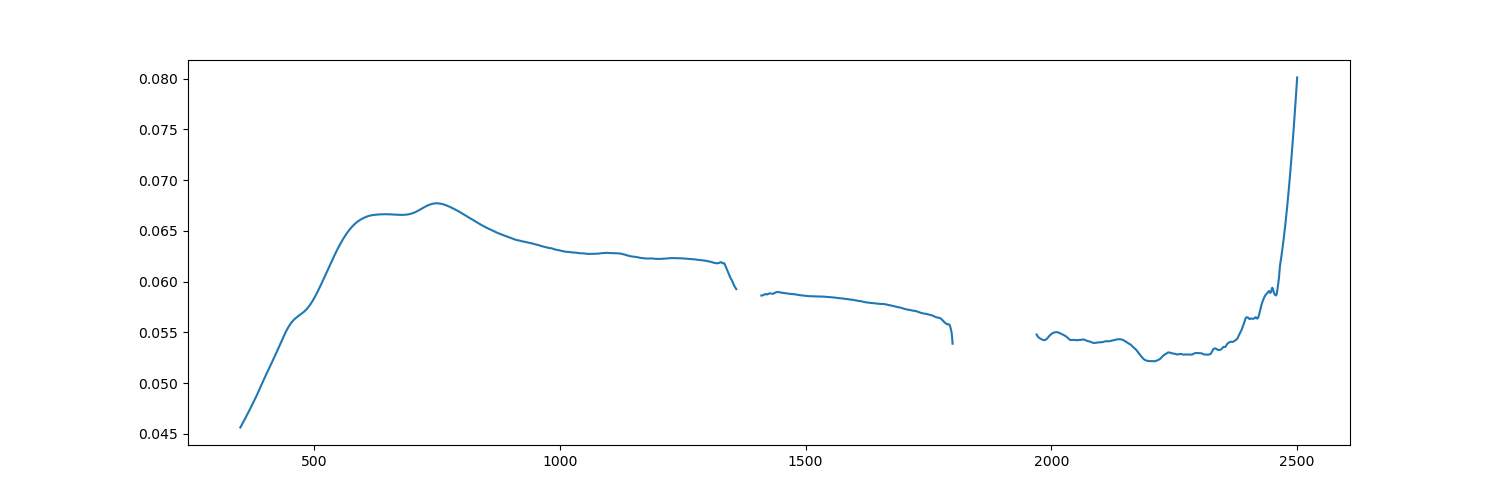

In [18]:
file_tag = '20250709_EL_val1'
site_fids = [x for x in fids if file_tag in x and '6c' in x]
insitu_rfl = insitu.loc[insitu['file_tag']==file_tag, wvl_cols].values[0,:]

fig = plt.figure(figsize=(15,5))
plt.plot(wl_asd, insitu_rfl, label='insitu rfl')

for fid in site_fids:
    row1, row2, col1, col2 = bboxes[file_tag][fid]
    fid_mini = '_'.join(fid.split('_')[0:3])
    fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
    modeled_rfl = envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :].copy()# .reshape(-1,426).T
    ndvi = np.true_divide((modeled_rfl[...,89]-modeled_rfl[...,57]),(modeled_rfl[...,89]+modeled_rfl[...,57]))
    modeled_rfl[ndvi>0.1] = np.nan
    modeled_rfl = modeled_rfl.reshape(-1,426).T
    # modeled_rfl = np.nanmean(modeled_rfl, axis=(0,1))
    plt.plot(wl_neon_nan, modeled_rfl, label=fid)

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

plt.show()

/tmp/ipykernel_757888/3554474040.py:13: RuntimeWarning: Mean of empty slice
  modeled_rfl = np.nanmean(modeled_rfl, axis=(0,1))


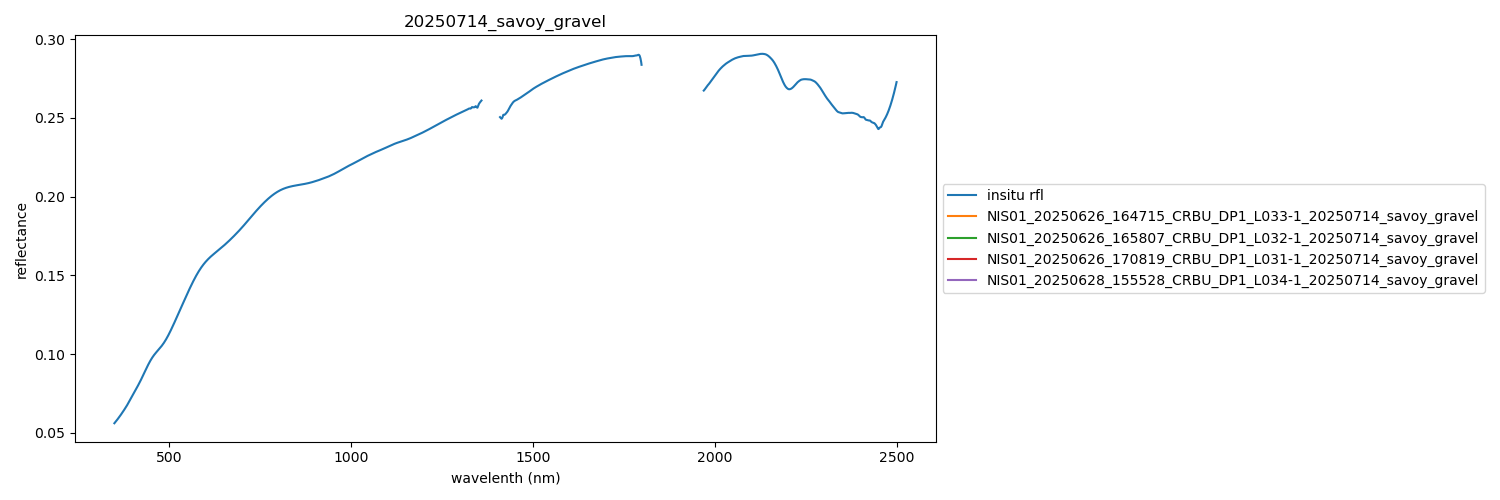

In [31]:
fig = plt.figure(figsize=(15,5))
plt.plot(wl_asd, insitu_rfl, label='insitu rfl')

for fid in site_fids:
    try:
        row1, row2, col1, col2 = bboxes[file_tag][fid.removesuffix('_6c')]
        fid_mini = '_'.join(fid.split('_')[0:3])
        fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
        modeled_rfl = envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :].copy()# .reshape(-1,426).T
        ndvi = np.true_divide((modeled_rfl[...,89]-modeled_rfl[...,57]),(modeled_rfl[...,89]+modeled_rfl[...,57]))
        modeled_rfl[ndvi>0.1] = np.nan
        # modeled_rfl = modeled_rfl.reshape(-1,426).T
        modeled_rfl = np.nanmean(modeled_rfl, axis=(0,1))
        plt.plot(wl_neon_nan, modeled_rfl, label=fid)
    except: pass

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

plt.show()

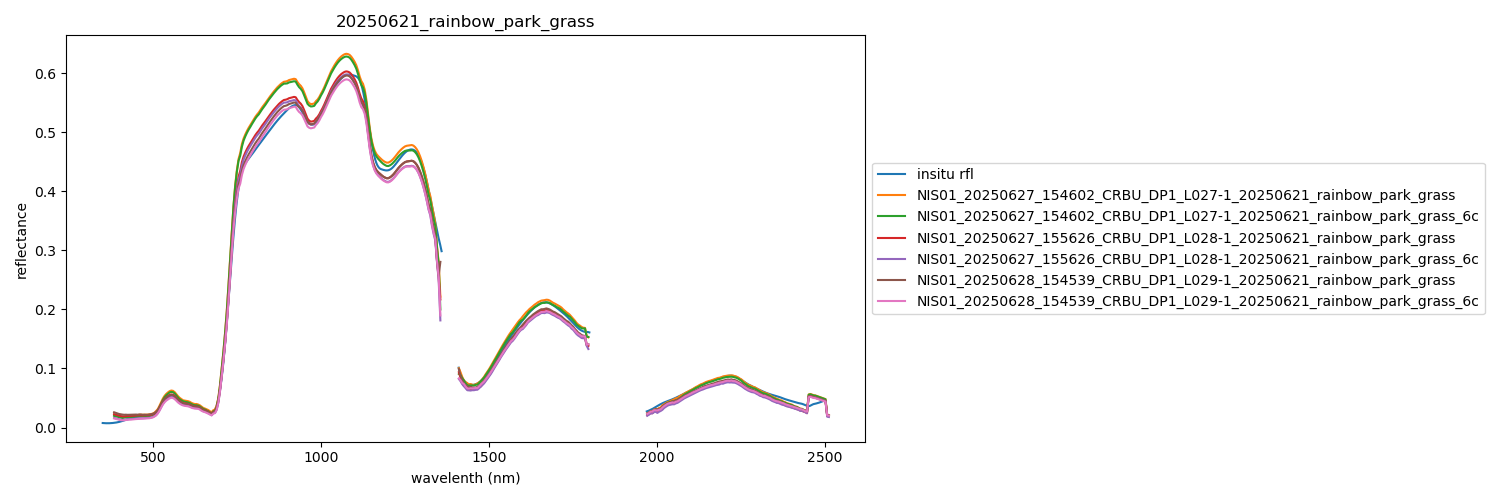

In [21]:
file_tag = '20250621_rainbow_park_grass'

site_fids = [x for x in fids if file_tag in x]
site_fids
insitu_rfl = insitu.loc[insitu['file_tag']==file_tag, wvl_cols].values[0,:]

fig = plt.figure(figsize=(15,5))
plt.plot(wl_asd, insitu_rfl, label='insitu rfl')

for fid in site_fids:
    try:
        row1, row2, col1, col2 = bboxes[file_tag][fid.removesuffix('_6c')]
        fid_mini = '_'.join(fid.split('_')[0:3])
        fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
        modeled_rfl = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
    
        plt.plot(wl_neon_nan, modeled_rfl, label=fid)
    except: pass

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

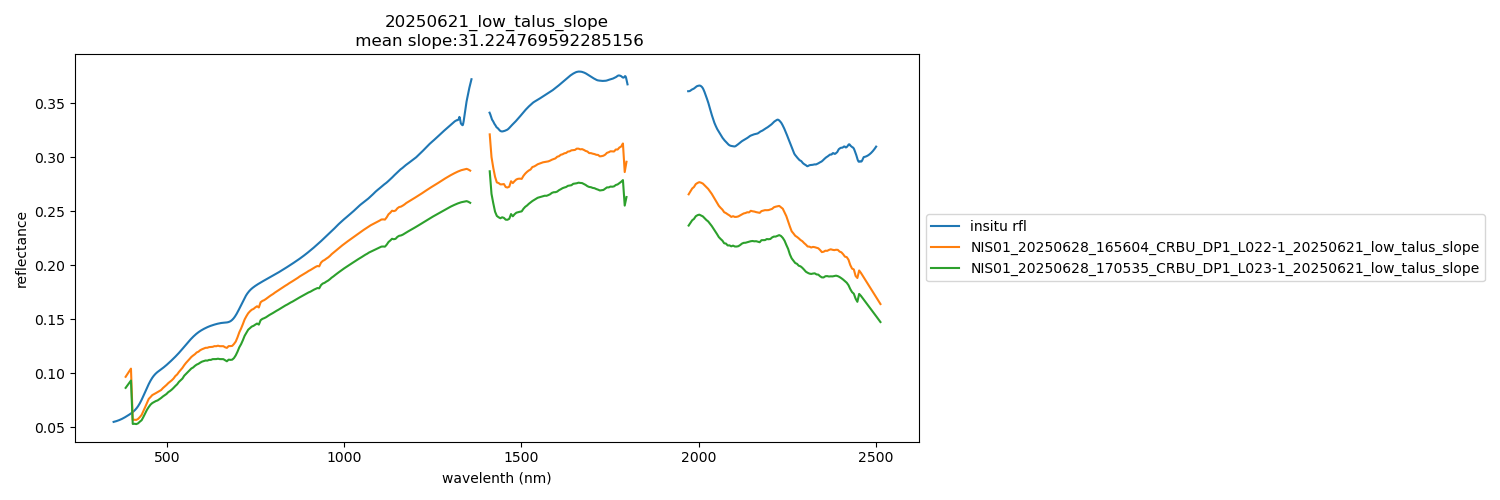

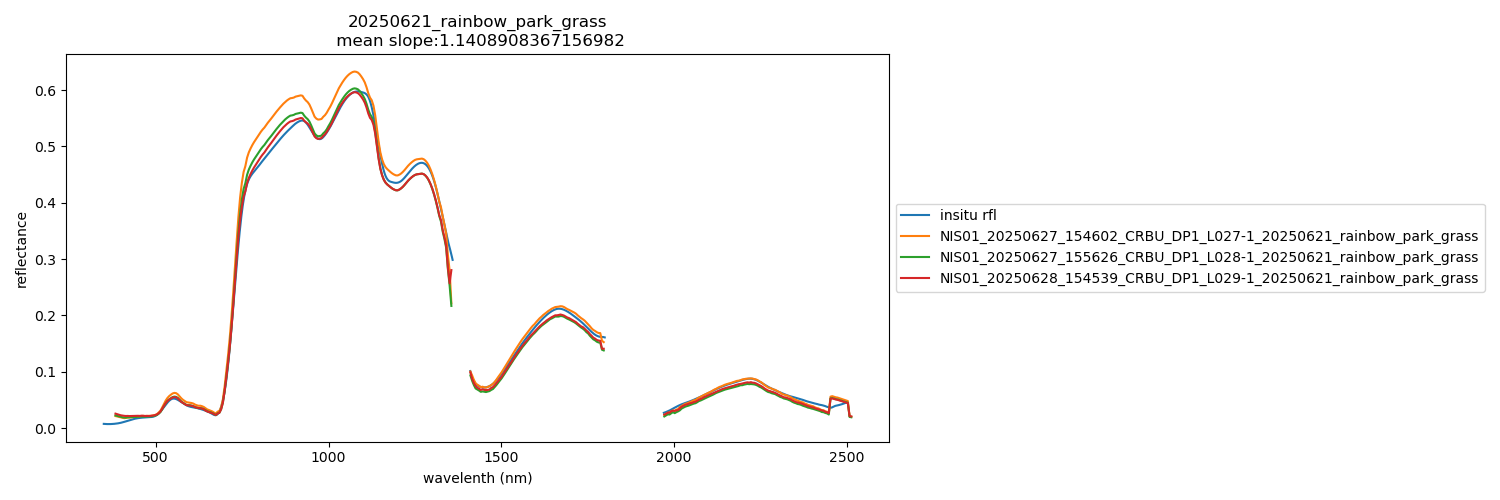

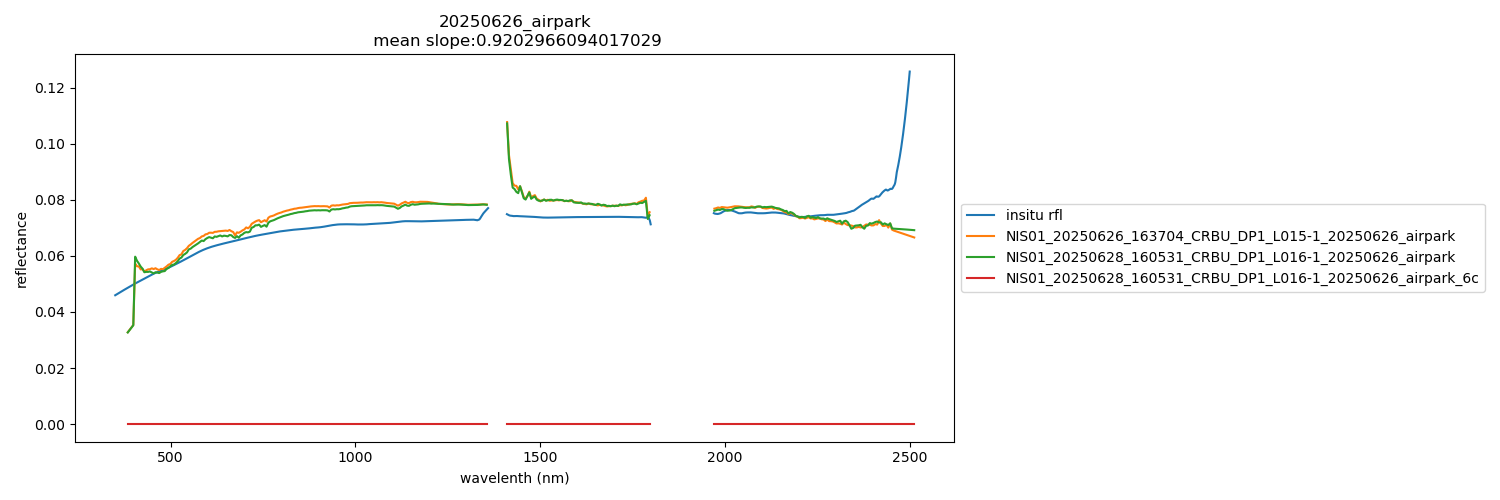

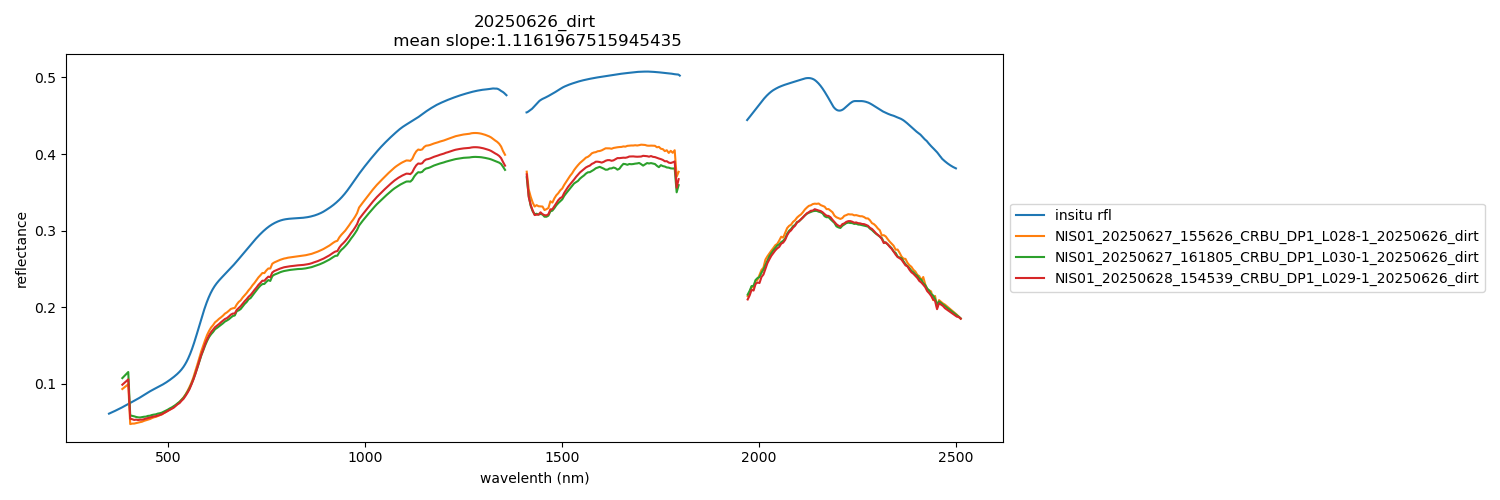

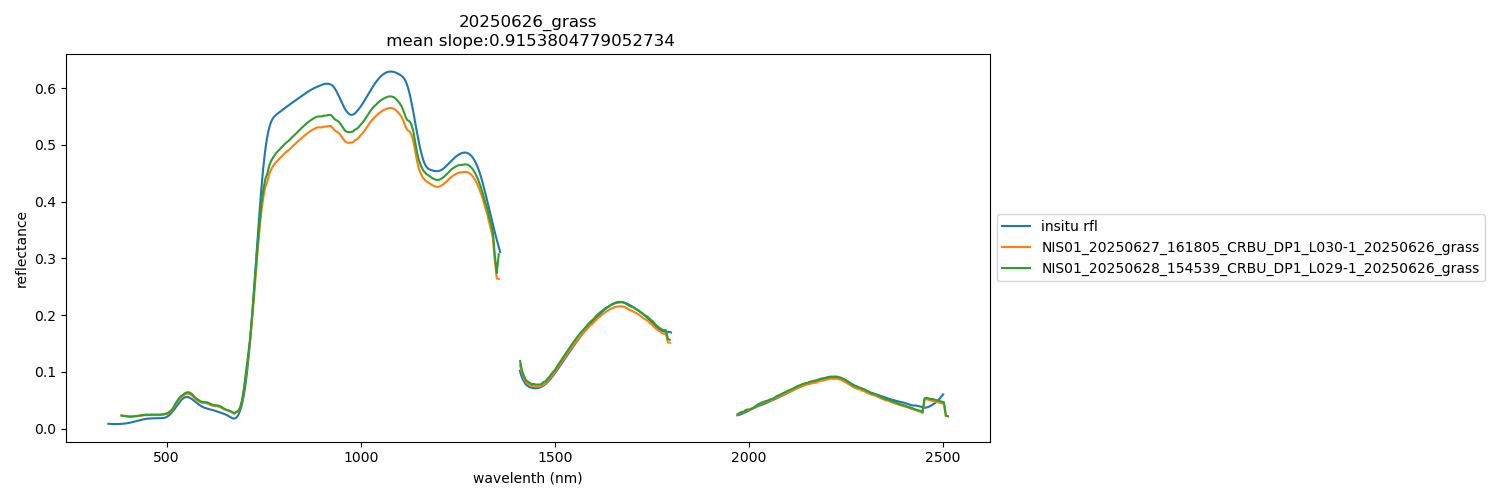

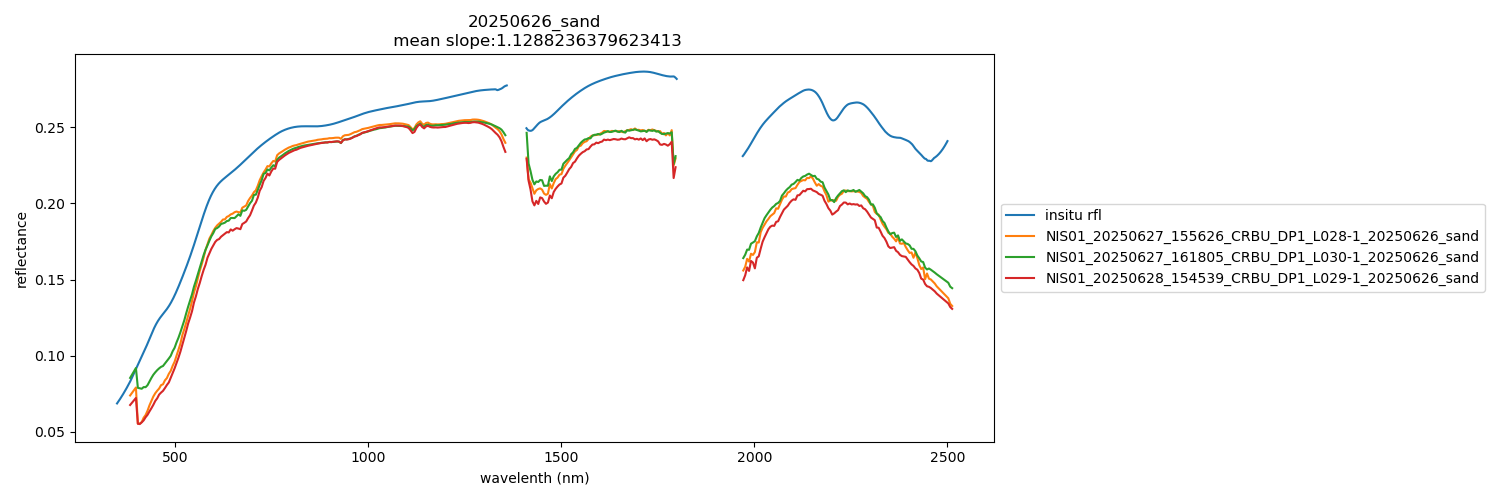

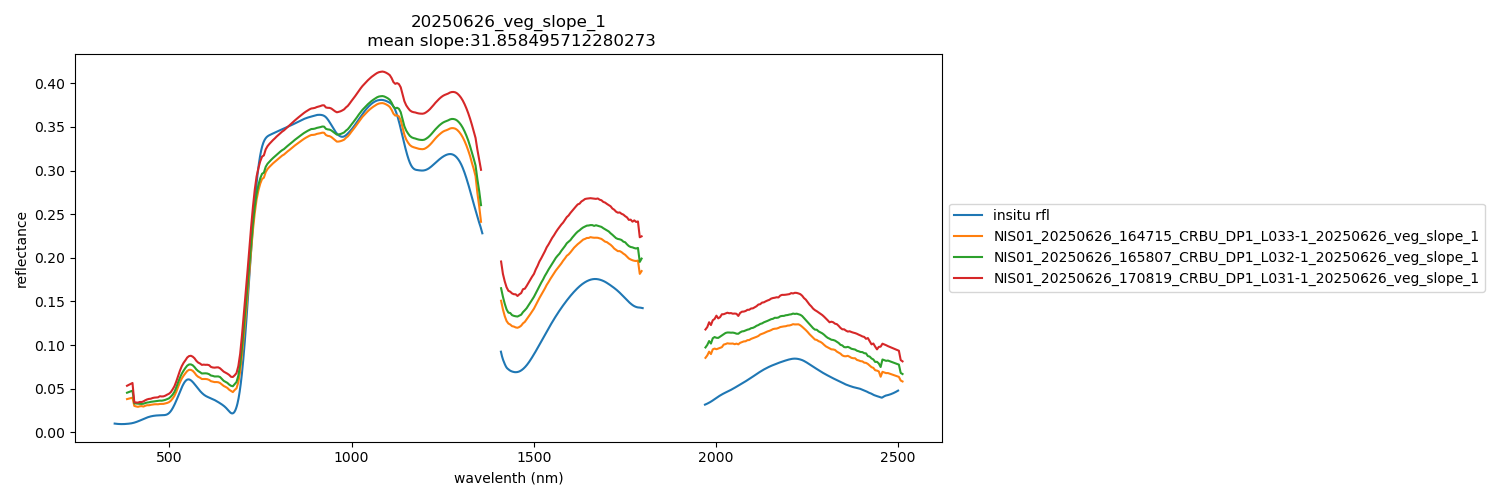

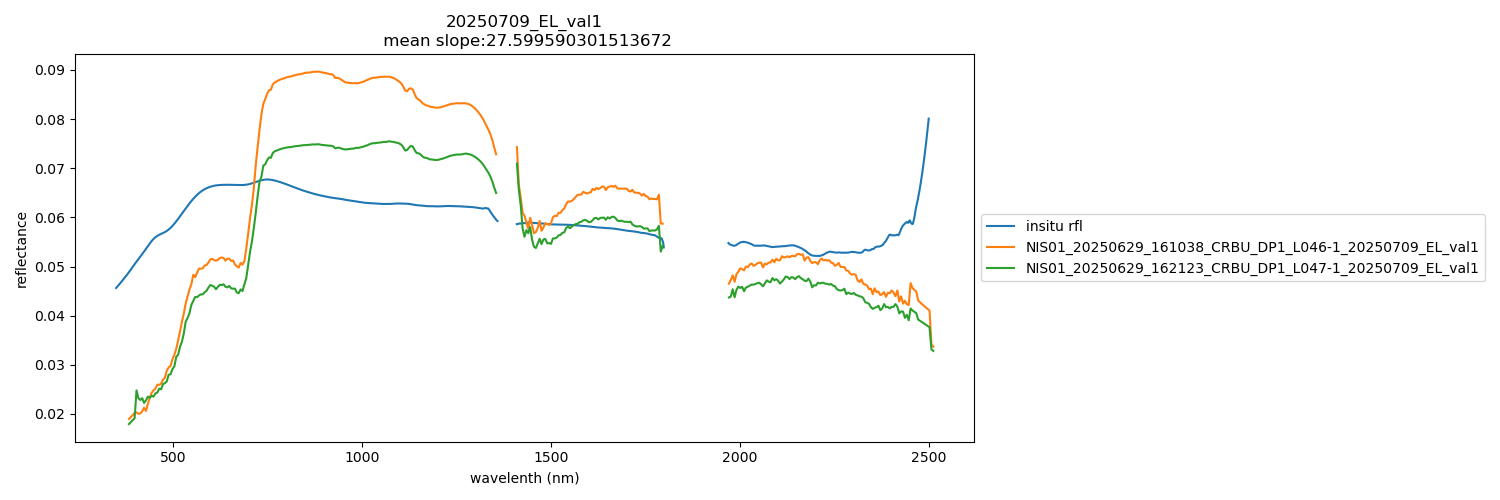

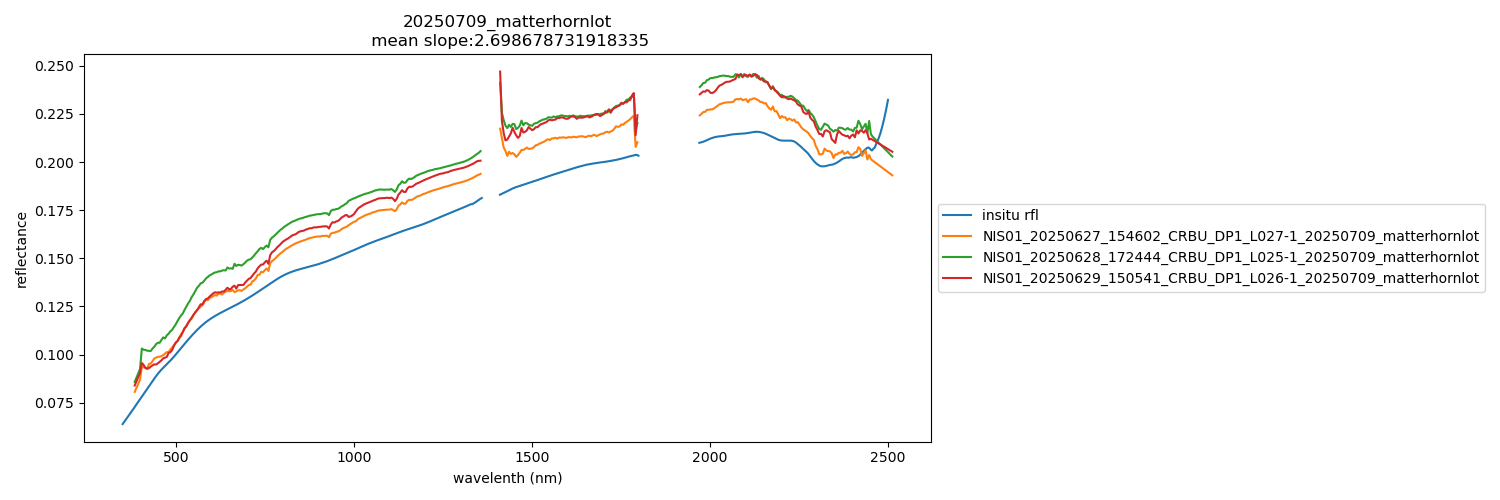

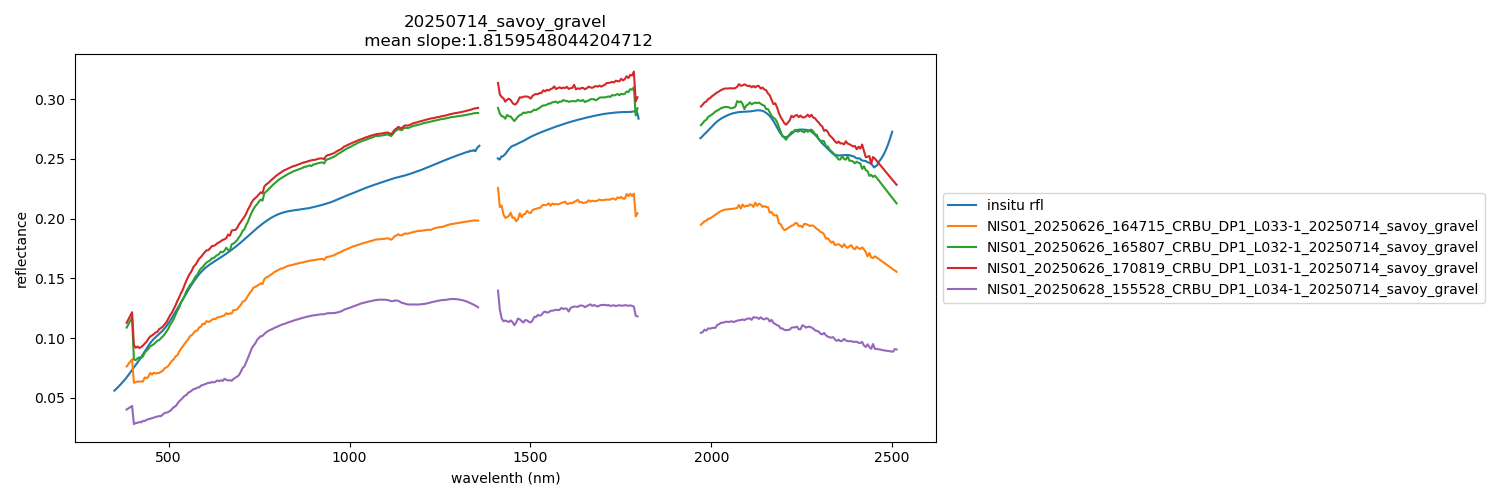

In [34]:
for file_tag in file_tags:
    site_fids = [x for x in fids if file_tag in x]
    insitu_rfl = insitu.loc[insitu['file_tag']==file_tag, wvl_cols].values[0,:]

    fig = plt.figure(figsize=(15,5))
    plt.plot(wl_asd, insitu_rfl, label='insitu rfl')
    
    for fid in site_fids:
        try:
            row1, row2, col1, col2 = bboxes[file_tag][fid.removesuffix('_6c')]
            fid_mini = '_'.join(fid.split('_')[0:3])
            fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
            modeled_rfl = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
            plt.plot(wl_neon_nan, modeled_rfl, label=fid)
        except: pass

    fid = site_fids[0]
    fp_obs = os.path.join('validation/subsets', f'{fid}_obs.hdr')
    mean_slope = np.nanmean(envi.open(fp_obs).open_memmap(interleave='bip')[row1:row2, col1:col2, 6], axis=(0,1))
    
    plt.xlabel('wavelenth (nm)')
    plt.ylabel('reflectance')
    plt.title(f'{file_tag}\n mean slope:{mean_slope}')
    # plt.legend()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    fig.tight_layout()

#    plt.show()

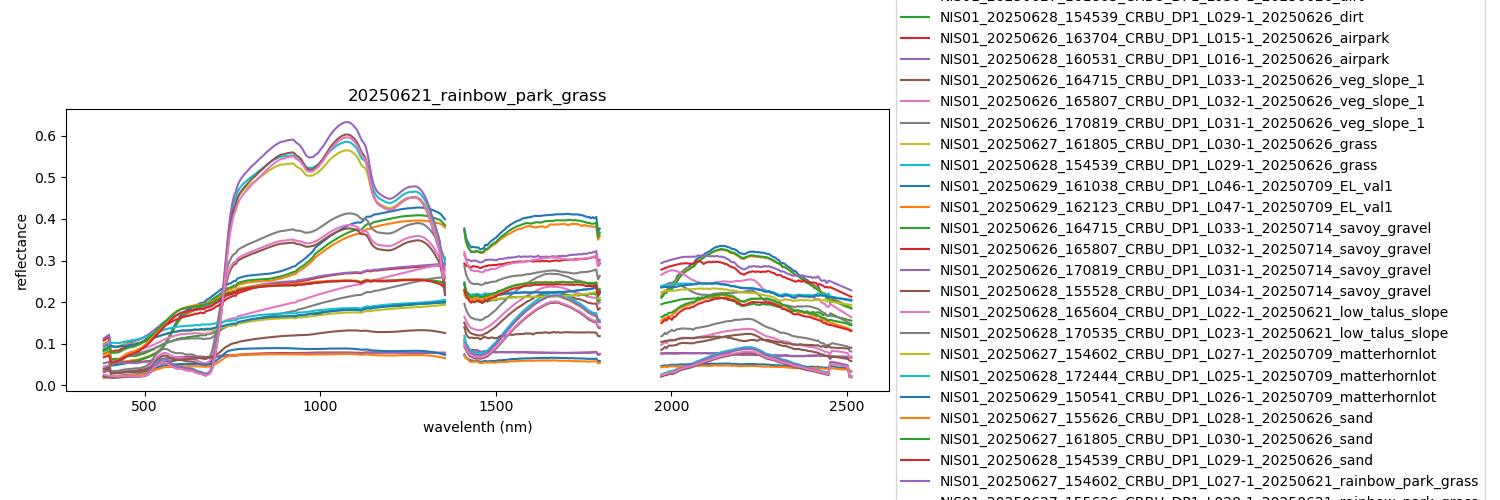

In [40]:
# look at all in situ rfl together

fig = plt.figure(figsize=(15,5))

for file_tag in file_tags:
    site_fids = [x for x in fids if file_tag in x]
    
    for fid in site_fids:
        row1, row2, col1, col2 = bboxes[file_tag][fid]
        fid_mini = '_'.join(fid.split('_')[0:3])
        fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
        modeled_rfl = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))

        plt.plot(wl_neon_nan, modeled_rfl, label=fid)

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

plt.show()